In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
%matplotlib inline

In [2]:
#Load Data

data = loadmat('v1_laminar.mat')
data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'csd', 'timevec', 'srate'])

In [4]:
# Extract Data

eeg_data = data['csd']
time_vector = data['timevec']
sampling_rate = data['srate'][0][0]
timepoints = len(time_vector[0])
nyquist = int(sampling_rate / 2)

eeg_data.shape, timepoints, nyquist

((16, 1527, 200), 1527, 381)

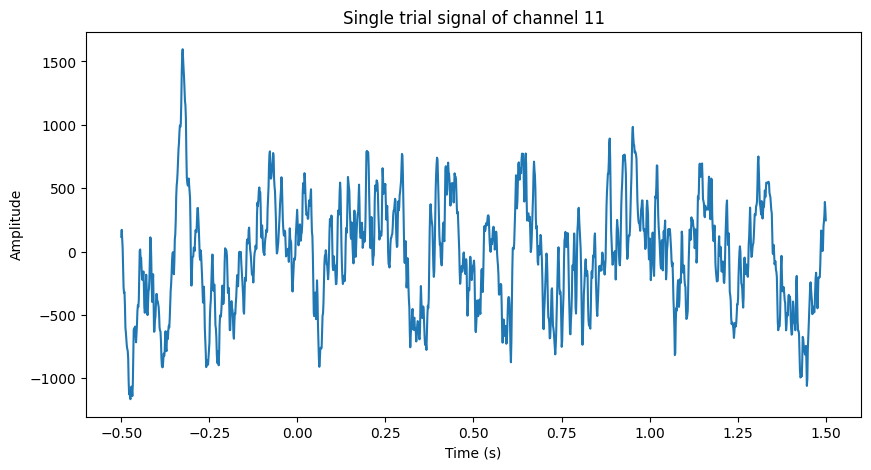

In [5]:
# Visualize Signal From A Single Channel And Trial

channel = 10
trial = 7

plt.close('all')
plt.subplots(1, 1, figsize=(10, 5))
plt.plot(time_vector[0], eeg_data[channel, :, trial])
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Single trial signal of channel {channel+1}')
plt.show()

In [ ]:
# Extracting Static Power

frequency_vector = np.linspace(0, nyquist, int(timepoints/2))
fourier_coeffients = np.fft.fft(eeg_data[channel, :, trial]) / timepoints

amplitude_spectrum = np.abs(fourier_coeffients)
amplitude_spectrum[1 : nyquist] = 2 * amplitude_spectrum[1 : nyquist]

power = 2 ** amplitude_spectrum

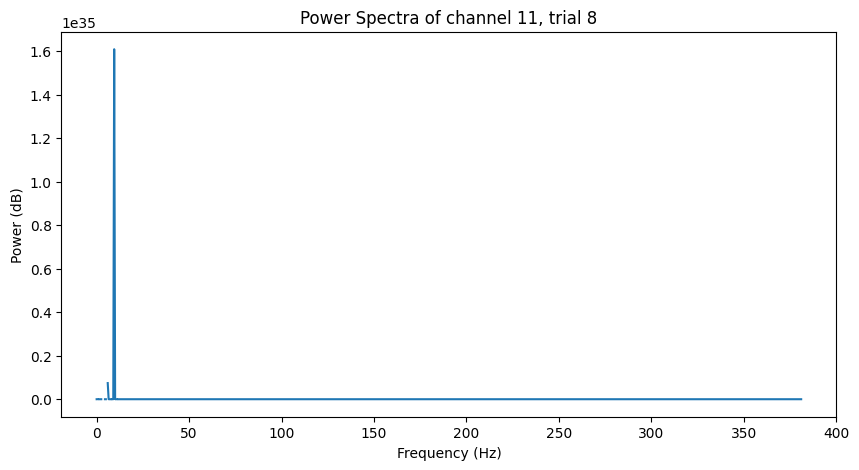

In [8]:
# Visualization Of Static Power

plt.close('all')
plt.subplots(1, 1, figsize=(10, 5))
plt.plot(frequency_vector, power[:len(frequency_vector)])
plt.title(f'Power Spectra of channel {channel+1}, trial {trial+1}')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (dB)')
plt.show()